In [ ]:
import cv2
import glob
import random
import pandas as pd
import gzip
import numpy as np
import xml.etree.ElementTree as ET
import torch
import torch.nn as nn
from torch.optim import Adam
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torchvision
from torchvision import transforms
from torch.utils.data import random_split, TensorDataset, DataLoader, Dataset, ConcatDataset
from sklearn.model_selection import train_test_split
!pip install torchmetrics
import torchmetrics
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.models.detection.roi_heads import RoIHeads
from torchvision.models.detection import roi_heads
from tqdm import tqdm
import matplotlib.pyplot as plt
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau, CyclicLR
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torch.amp import GradScaler, autocast
from torchvision.ops import nms
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

# Load Images and Labels

In [ ]:
# Step 1: Install and Set Up Kaggle
from google.colab import files
import os

# Upload kaggle.json
print("Upload Kaggle API key (kaggle.json):")
files.upload()

# Create the .kaggle directory
os.makedirs('/root/.kaggle/', exist_ok=True)

# Move kaggle.json to the .kaggle directory
!mv kaggle.json /root/.kaggle/

# Change permissions for the kaggle.json file
!chmod 600 /root/.kaggle/kaggle.json

# Install Kaggle CLI
!pip install kaggle

# Download the dataset
!kaggle datasets download -d andrewmvd/face-mask-detection

# Unzip the dataset
!unzip face-mask-detection.zip -d /content/dataset

# Step 2: Import Required Libraries
import glob
import cv2
import os
import xml.etree.ElementTree as ET

# Step 3: Specify Image and Annotation Directories
image_dir = '/content/dataset/images'
xml_dir = '/content/dataset/annotations'

# Step 4: Load Images
image_paths = sorted(glob.glob(os.path.join(image_dir, '*.png')))  # Adjust extension if needed
images = [cv2.imread(img_path) for img_path in image_paths]

# Step 5: Parse XML Annotations
def parse_xml(xml_file):
    """
    Parse an XML annotation file and extract object details.
    """
    tree = ET.parse(xml_file)
    root = tree.getroot()

    # Initialize an empty list to store object details
    annotations = []

    # Iterate over each object in the XML
    for obj in root.findall('object'):
        # Extract the label or class name
        label = obj.find('name').text

        # Extract bounding box coordinates
        bbox = obj.find('bndbox')
        xmin = int(bbox.find('xmin').text)
        ymin = int(bbox.find('ymin').text)
        xmax = int(bbox.find('xmax').text)
        ymax = int(bbox.find('ymax').text)

        # Append annotation as a dictionary
        annotations.append({
            "label": label,
            "bbox": [xmin, ymin, xmax, ymax]
        })

    return annotations

# Step 6: Process Annotations
annotations_dict = {}

# Loop through all XML files in the annotations directory
for xml_file in os.listdir(xml_dir):
    # Extract the image ID (assuming the file name is the image ID)
    image_id = os.path.splitext(xml_file)[0]
    # Parse the XML file and get annotations
    annotations = parse_xml(os.path.join(xml_dir, xml_file))
    # Store annotations in a dictionary with image_id as key
    annotations_dict[image_id] = annotations

# Sort annotations dictionary
annotations_dict = dict(sorted(annotations_dict.items()))


Upload your Kaggle API key (kaggle.json):


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/face-mask-detection
License(s): CC0-1.0
 95% 377M/398M [00:02<00:00, 101MB/s]
100% 398M/398M [00:02<00:00, 141MB/s]
Archive:  face-mask-detection.zip
  inflating: /content/dataset/annotations/maksssksksss0.xml  
  inflating: /content/dataset/annotations/maksssksksss1.xml  
  inflating: /content/dataset/annotations/maksssksksss10.xml  
  inflating: /content/dataset/annotations/maksssksksss100.xml  
  inflating: /content/dataset/annotations/maksssksksss101.xml  
  inflating: /content/dataset/annotations/maksssksksss102.xml  
  inflating: /content/dataset/annotations/maksssksksss103.xml  
  inflating: /content/dataset/annotations/maksssksksss104.xml  
  inflating: /content/dataset/annotations/maksssksksss105.xml  
  inflating: /content/dataset/annotations/maksssksksss106.xml  
  inflating: /content/dataset/annotations/maksssksksss107.xml  
  inflating: /content/dataset/annotations/maksssksksss108.xml 

In [ ]:
# Check labels for first image
annotations_dict['maksssksksss0']

[{'label': 'without_mask', 'bbox': [79, 105, 109, 142]},
 {'label': 'with_mask', 'bbox': [185, 100, 226, 144]},
 {'label': 'without_mask', 'bbox': [325, 90, 360, 141]}]

In [ ]:
len(images)

853

## Display samples (CV or Matplotlib)

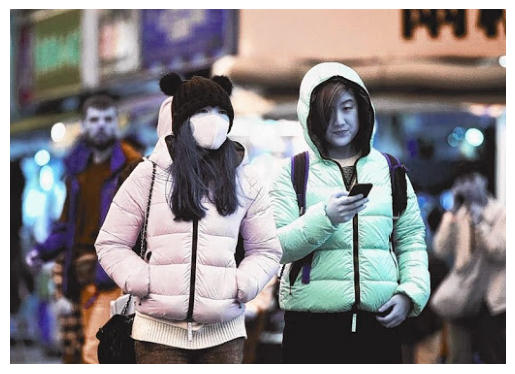

In [ ]:
sample = images[0]

# Display the image using Matplotlib
plt.imshow(sample)
plt.axis('off')  # Remove axis for better visualization
plt.show()

### Store labels and bboxes

In [ ]:
bounding_list = []
labels_list = []
label_map = {'background': 0, 'with_mask': 1, 'without_mask': 2, 'mask_weared_incorrect':3}

In [ ]:
for indx, (image_ID, image_info) in enumerate(annotations_dict.items()):
    bboxes = []
    labelss = []
    for each in image_info:
        xmin, ymin, xmax, ymax = each["bbox"]
        label = each['label']
        bboxes.append([xmin, ymin, xmax, ymax])
        labelss.append(label_map[label])
    bounding_list.append(bboxes)
    labels_list.append(labelss)

In [ ]:
len(bounding_list)

853

In [ ]:
len(labels_list)

853

## Draw the region of mask

In [ ]:
import matplotlib.patches as patches

In [ ]:
def show_image_with_bounding_boxes(image, annotations):
    # Display the image
    plt.imshow(image)
    ax = plt.gca()  # Get current axes for adding bounding boxes

    # Draw bounding boxes with labels
    for annotation in annotations:
        label = annotation["label"]
        xmin, ymin, xmax, ymax = annotation["bbox"]

        # Create a rectangle patch for the bounding box
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor='green', facecolor='none'
        )
        ax.add_patch(rect)  # Add the bounding box to the plot

        # Add label text
        ax.text(xmin-10, ymin - 28, label, color='yellow', fontsize=10, weight='bold')

    plt.axis('off')  # Hide axis
    plt.show()

## Display sample with bounding box of masks

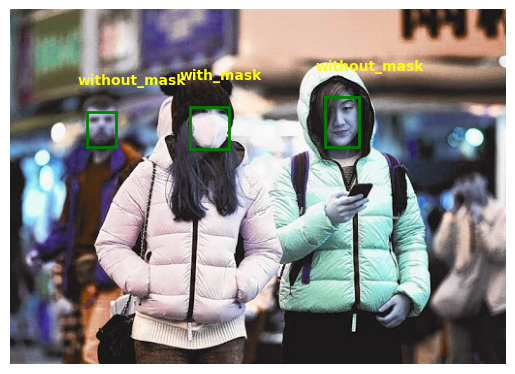

In [ ]:
## First image
show_image_with_bounding_boxes(images[0], annotations_dict['maksssksksss0'])

## Randomly split the training and test sets with ratio 70% and 30% (We'll apply augmentations to only training set)

In [ ]:
# Split train and test first
train_images, test_images, train_bboxes, test_bboxes, train_labels, test_labels = train_test_split(
    images, bounding_list, labels_list, test_size=0.3, random_state=42)

In [ ]:
# Split test again to get validation and test
test_images, validation_images, test_bboxes, validation_bboxes, test_labels, validation_labels = train_test_split(
    test_images, test_bboxes, test_labels, test_size=0.5, random_state=42)

## Data Augmentation (Applied to training set)

### Create augmentations to increase the diversity

In [ ]:
augmentations_6 = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.5, contrast_limit=0.5, p=0.5),
    A.ChannelShuffle(p=0.3),
    A.GaussianBlur(blur_limit=(3, 7), p=0.2),
    ToTensorV2(),
], bbox_params=A.BboxParams(format='pascal_voc', clip=True, label_fields=['labels'], min_visibility=0.1))

In [ ]:
images_copy = train_images.copy()

In [ ]:
def augment(imgs, labels, boxes):
    aug_images = []
    aug_bboxes = []
    aug_labels = []
    original_images = images_copy
    for i, x in enumerate(imgs):
        img = x
        box = boxes[i]
        label = labels[i]
        try:
            aug = augmentations_6(image=img, bboxes=box, labels=label)
            aug_img, aug_box, aug_label = aug['image'].numpy().transpose(1, 2, 0), aug['bboxes'], aug['labels']
            if not any(np.array_equal(aug_img, img) for img in original_images):
                aug_images.append(aug_img)
                aug_bboxes.append(aug_box)
                aug_labels.append(aug_label)
                original_images.append(aug_img)
        except:
            continue

    return aug_images, aug_bboxes, aug_labels

In [ ]:
aug_images, aug_bboxes, aug_labels = augment(train_images, train_labels, train_bboxes)

#### Inspect the number of classes

In [ ]:
w = sum(1 for i in train_labels for j in i if j == 1) # class 1
wo = sum(1 for i in train_labels for j in i if j == 2) # 2
ic = sum(1 for i in train_labels for j in i if j == 3) # 3

In [ ]:
print(f'Before augmentation, with mask: {w}, ratio: {w/(w+wo+ic):.4f}')
print(f'Before augmentation, without mask: {wo}, ratio: {wo/(w+wo+ic):.4f}')
print(f'Before augmentation, weared incorrect: {ic}, ratio: {ic/(w+wo+ic):.4f}')

Before augmentation, with mask: 2356, ratio: 0.8044
Before augmentation, without mask: 482, ratio: 0.1646
Before augmentation, weared incorrect: 91, ratio: 0.0311


### Concat the non aug and aug labels and bboxes together

In [ ]:
## Images, Bboxes and labels
images_combined = train_images + aug_images
bboxes_combined = train_bboxes + aug_bboxes
labels_combined = train_labels + aug_labels

In [ ]:
## Check length of all images, labels and bboxes
len(images_combined), len(bboxes_combined), len(labels_combined)

(1117, 1117, 1117)

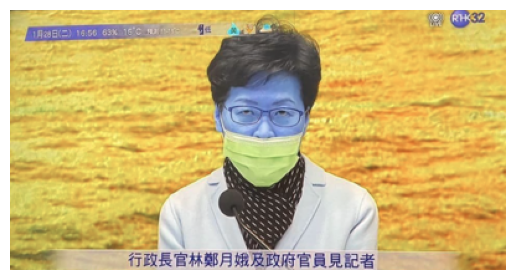

In [ ]:
plt.imshow(images_combined[10])
plt.axis('off')  # Remove axis for better visualization
plt.show()

In [ ]:
images_combined[0].shape

(301, 400, 3)

#### Check number of each classes after data augmentation for the entire new dataset

In [ ]:
w = sum(1 for i in labels_combined for j in i if j == 1) # class 1
wo = sum(1 for i in labels_combined for j in i if j == 2) # 2
ic = sum(1 for i in labels_combined for j in i if j == 3) # 3

In [ ]:
print(f'After augmentation, with mask: {w}, ratio: {w/(w+wo+ic):.4f}')
print(f'After augmentation, without mask: {wo}, ratio: {wo/(w+wo+ic):.4f}')
print(f'After augmentation, weared incorrect: {ic}, ratio: {ic/(w+wo+ic):.4f}')

After augmentation, with mask: 4282, ratio: 0.8017
After augmentation, without mask: 888, ratio: 0.1663
After augmentation, weared incorrect: 171, ratio: 0.0320


#### The class is still not balanced, we will deal with that by customizing class weights for the loss function in our model.

## Preprocess images

In [ ]:
# Resize the image size (square)
target_size = (376, 376)

In [ ]:
# Prepross function
def preprocess_images(images, target_size):
    # Store in a list
    preprocessed_images = []

    for image in images:
        # Resize the image
        resized_image = cv2.resize(image, target_size)

        # Convert BGR to RGB if necessary
        if len(resized_image.shape) == 3 and resized_image.shape[2] == 3:
            rgb_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB)

        # Normalize pixel values to [0, 1]
        normalized_image = rgb_image / 255.0

        # Convert to tensor and rearrange to (channels, height, width)
        tensor_image = torch.tensor(normalized_image, dtype=torch.float32).permute(2, 0, 1)

        # Append to the list
        preprocessed_images.append(tensor_image)

    return preprocessed_images

In [ ]:
train_images_pp = preprocess_images(images_combined, target_size)
test_images_pp = preprocess_images(test_images, target_size)
validation_images_pp = preprocess_images(validation_images, target_size)

In [ ]:
train_images_pp[0].shape

torch.Size([3, 376, 376])

## Display the sample image after preprocessed

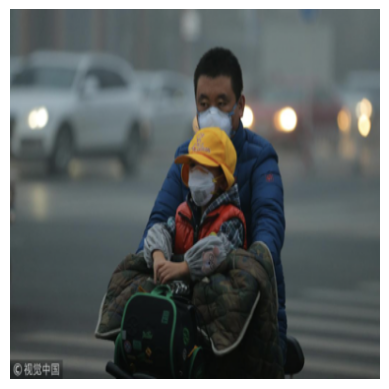

In [ ]:
# Select the first preprocessed image
sample_image_tensor = train_images_pp[300]  # Choose any index, e.g., 0 for the first image

# Convert tensor to NumPy for displaying
# PyTorch tensor shape is (C, H, W), we need to convert it to (H, W, C) for display
sample_image = sample_image_tensor.permute(1, 2, 0).numpy()

# Display the image using Matplotlib
plt.imshow(sample_image)
plt.axis('off')  # Remove axis for better visualization
plt.show()

## Display the sample image with bounding box after preprocessed

In [ ]:
def image_pp_bbox(new_image, bboxes, old_image, labels):
    # Display the image
    plt.imshow(new_image)
    ax = plt.gca()  # Get current axes for adding bounding boxes

    # Calculate scale factors
    original_width = old_image.shape[1]
    original_height = old_image.shape[0]
    new_width = new_image.shape[1]
    new_height = new_image.shape[0]
    scale_x = new_width / original_width
    scale_y = new_height / original_height

    # Draw bounding boxes with labels
    for i, box in enumerate(bboxes):
        if labels[i] == 1:
            label = 'with_mask'
        elif labels[i] == 2:
            label = 'without_mask'
        else:
            label = 'mask_weared_incorrect'

        xmin, ymin, xmax, ymax = box

        # Calculate the new x and y positions based on the shifting scale
        xmin = int(xmin * scale_x)
        ymin = int(ymin * scale_y)
        xmax = int(xmax * scale_x)
        ymax = int(ymax * scale_y)

        # Create a rectangle patch for the bounding box
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor='green', facecolor='none'
        )
        ax.add_patch(rect)  # Add the bounding box to the plot

        # Add label text
        ax.text(xmin, ymin, label, color='yellow', fontsize=10, weight='bold')

    plt.axis('off')  # Hide axis
    plt.show()

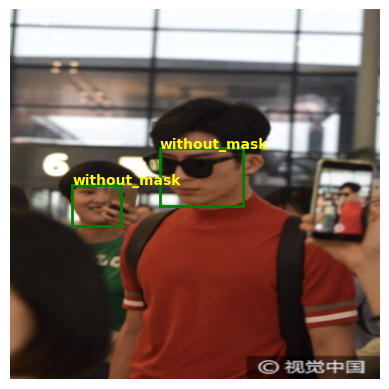

In [ ]:
## Display the first preprocessed image
image_pp_bbox(train_images_pp[500].permute(1, 2, 0).numpy(), bboxes_combined[500], images_combined[500], labels_combined[500])

## Convert each object(mask)'s bounding coordinates and associated labels to numerics

In [ ]:
train_boxes_tensor = []
train_labels_tensor = []
test_boxes_tensor = []
test_labels_tensor = []
val_boxes_tensor = []
val_labels_tensor = []
label_map = {'background': 0, 'with_mask': 1, 'without_mask': 2, 'mask_weared_incorrect':3}

In [ ]:
# Train
for indx, image in enumerate(train_images_pp):
    bl = []
    ll = []
    bboxes = bboxes_combined[indx]
    labelss = labels_combined[indx]
    original_image = images_combined[indx]
    for box in bboxes:
        xmin, ymin, xmax, ymax = box
        original_height, original_width = original_image.shape[0:2]
        scale_x = target_size[1] / original_width
        scale_y = target_size[0] / original_height
        # Adjust coordinates for x and y
        xmin = xmin*scale_x
        ymin = ymin*scale_y
        xmax = xmax*scale_x
        ymax = ymax*scale_y

        bl.append([xmin, ymin, xmax, ymax])

    for lb in labelss:
        ll.append(lb)

    train_boxes_tensor.append(torch.tensor(bl, dtype=torch.float32))
    train_labels_tensor.append(torch.tensor(ll, dtype=torch.int64))

In [ ]:
# Test
for indx, image in enumerate(test_images_pp):
    bl = []
    ll = []
    bboxes = test_bboxes[indx]
    labelss = test_labels[indx]
    original_image = test_images[indx]
    for box in bboxes:
        xmin, ymin, xmax, ymax = box
        original_height, original_width = original_image.shape[0:2]
        scale_x = target_size[1] / original_width
        scale_y = target_size[0] / original_height
        # Adjust coordinates for x and y
        xmin = xmin*scale_x
        ymin = ymin*scale_y
        xmax = xmax*scale_x
        ymax = ymax*scale_y

        bl.append([xmin, ymin, xmax, ymax])

    for lb in labelss:
        ll.append(lb)

    test_boxes_tensor.append(torch.tensor(bl, dtype=torch.float32))
    test_labels_tensor.append(torch.tensor(ll, dtype=torch.int64))

In [ ]:
# Validation
for indx, image in enumerate(validation_images_pp):
    bl = []
    ll = []
    bboxes = validation_bboxes[indx]
    labelss = validation_labels[indx]
    original_image = validation_images[indx]
    for box in bboxes:
        xmin, ymin, xmax, ymax = box
        original_height, original_width = original_image.shape[0:2]
        scale_x = target_size[1] / original_width
        scale_y = target_size[0] / original_height
        # Adjust coordinates for x and y
        xmin = xmin*scale_x
        ymin = ymin*scale_y
        xmax = xmax*scale_x
        ymax = ymax*scale_y

        bl.append([xmin, ymin, xmax, ymax])

    for lb in labelss:
        ll.append(lb)

    val_boxes_tensor.append(torch.tensor(bl, dtype=torch.float32))
    val_labels_tensor.append(torch.tensor(ll, dtype=torch.int64))

In [ ]:
train_images_pp[0:1]

[tensor([[[0.0706, 0.0941, 0.1098,  ..., 0.4353, 0.5137, 0.5725],
          [0.0706, 0.0902, 0.1137,  ..., 0.4353, 0.4902, 0.5529],
          [0.0784, 0.0863, 0.1176,  ..., 0.4353, 0.4902, 0.5529],
          ...,
          [0.8667, 0.8510, 0.8745,  ..., 0.4118, 0.3961, 0.4118],
          [0.8667, 0.8471, 0.8706,  ..., 0.4039, 0.4039, 0.4196],
          [0.8784, 0.8510, 0.8667,  ..., 0.4078, 0.4118, 0.4392]],
 
         [[0.0941, 0.1255, 0.1412,  ..., 0.4549, 0.5333, 0.5882],
          [0.1020, 0.1176, 0.1451,  ..., 0.4549, 0.5098, 0.5725],
          [0.1059, 0.1176, 0.1451,  ..., 0.4549, 0.5098, 0.5725],
          ...,
          [0.7490, 0.7255, 0.7451,  ..., 0.1451, 0.1333, 0.1490],
          [0.7451, 0.7176, 0.7333,  ..., 0.1373, 0.1373, 0.1490],
          [0.7529, 0.7176, 0.7255,  ..., 0.1333, 0.1333, 0.1490]],
 
         [[0.1529, 0.1882, 0.2078,  ..., 0.5137, 0.5843, 0.6353],
          [0.1569, 0.1804, 0.2118,  ..., 0.5137, 0.5608, 0.6157],
          [0.1608, 0.1765, 0.2157,  ...,

In [ ]:
train_boxes_tensor[200:202]

[tensor([[113.7400, 136.3000, 286.7000, 334.6400]]),
 tensor([[ 55.4600, 246.2800,  60.1600, 259.4400],
         [ 77.0800, 238.7600,  83.6600, 251.9200],
         [ 94.9400, 266.9600,  98.7000, 274.4800],
         [104.3400, 248.1600, 109.0400, 259.4400],
         [118.4400, 246.2800, 124.0800, 259.4400],
         [125.9600, 251.9200, 130.6600, 263.2000],
         [134.4200, 251.9200, 140.0600, 261.3200],
         [159.8000, 266.9600, 169.2000, 285.7600],
         [211.5000, 197.4000, 220.9000, 219.9600],
         [261.3200, 188.0000, 270.7200, 212.4400]])]

In [ ]:
for i, tensor in enumerate(train_boxes_tensor):
    if tensor.numel() == 0:
        print(f'Tensor at index {i} is empty.')

## We'll deal with it in collate function

In [ ]:
train_labels_tensor[100:102]

[tensor([1, 1, 1, 1, 1, 1, 1, 1]), tensor([1, 1, 1, 1, 1, 1])]

In [ ]:
len(train_boxes_tensor)

1117

In [ ]:
len(train_labels_tensor)

1117

## Prepare data for PyTorch

### Create Datasets for training, validation and test

In [ ]:
class CreateDataset(Dataset):
    def __init__(self, images, bboxes, labels):
        self.images = images
        self.bboxes = bboxes
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Return image and its corresponding bounding boxes and labels
        image = self.images[idx]
        boxes = self.bboxes[idx]
        labels = self.labels[idx]

        # Group bounding boxes and labels into target
        target = {
            "boxes": boxes,
            "labels": labels
     #       "image_id": torch.tensor([idx])  # Optional
        }

        return image, target


In [ ]:
train_dataset = CreateDataset(train_images_pp, train_boxes_tensor, train_labels_tensor)
test_dataset = CreateDataset(test_images_pp, test_boxes_tensor, test_labels_tensor)
val_dataset = CreateDataset(validation_images_pp, val_boxes_tensor, val_labels_tensor)

In [ ]:
train_dataset[609][1]['boxes'].numel()

4

## Check the shape of both datasets are correct

In [ ]:
print(f'Shape of 1st Training image: {train_dataset[0][0].shape}')
print(f'Shape of 300th augmented training image: {train_dataset[299][0].shape}')
#print(f'Shape of 1st Test image: {test_data[0][0].shape}')
#print(f'Shape of 1st Validation image: {val_data[100][0].shape}')

Shape of 1st Training image: torch.Size([3, 376, 376])
Shape of 300th augmented training image: torch.Size([3, 376, 376])


In [ ]:
#train_data, test_data = random_split(dataset, [0.7, 0.3])

In [ ]:
#test_data, val_data = random_split(test_data, [0.5, 0.5])

In [ ]:
print(f'The train data length is {len(train_dataset)}')
print(f'The test data length is {len(test_dataset)}')
print(f'The validation data length is {len(val_dataset)}')

The train data length is 1117
The test data length is 128
The validation data length is 128


In [ ]:
def collate_fn(batch):
    # None/Empty bounding box found when inspecting data -> Remove None/Empty samples
    batch = [item for item in batch if item[1]['boxes'].numel() != 0]
    images = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    # We need to stack all images in each batch into a single tensor (stack 8 images into 1 tensor rather than a list of 8 tensors if batch size is 8)
    images = torch.stack(images, dim=0)
    return images, targets

In [ ]:
# Create trainloader validationloader and testloader for batching
trainloader = DataLoader(train_dataset, batch_size=14, collate_fn=collate_fn, shuffle=True, pin_memory=True)
valloader = DataLoader(val_dataset, batch_size=14, collate_fn=collate_fn, shuffle=False, pin_memory=True)
testloader = DataLoader(test_dataset, batch_size=14, collate_fn=collate_fn, shuffle=False, pin_memory=True)

In [ ]:
len(trainloader.dataset)

1117

In [ ]:
len(testloader.dataset)

128

In [ ]:
len(valloader.dataset)

128

In [ ]:
for images, targets in trainloader:
    print(images[0], targets[0])
    break

tensor([[[0.0039, 0.0000, 0.0039,  ..., 0.0078, 0.0078, 0.0078],
         [0.0039, 0.0000, 0.0000,  ..., 0.0078, 0.0078, 0.0078],
         [0.0039, 0.0039, 0.0039,  ..., 0.0078, 0.0078, 0.0078],
         ...,
         [0.1137, 0.1020, 0.0941,  ..., 0.0588, 0.0588, 0.0588],
         [0.0902, 0.0863, 0.0902,  ..., 0.0549, 0.0510, 0.0510],
         [0.0784, 0.0745, 0.0824,  ..., 0.0510, 0.0510, 0.0510]],

        [[0.0078, 0.0039, 0.0078,  ..., 0.0157, 0.0157, 0.0157],
         [0.0078, 0.0078, 0.0078,  ..., 0.0157, 0.0118, 0.0118],
         [0.0118, 0.0118, 0.0118,  ..., 0.0157, 0.0157, 0.0157],
         ...,
         [0.1176, 0.1059, 0.0980,  ..., 0.0627, 0.0627, 0.0627],
         [0.0941, 0.0902, 0.0902,  ..., 0.0588, 0.0588, 0.0588],
         [0.0824, 0.0784, 0.0863,  ..., 0.0549, 0.0549, 0.0549]],

        [[0.0118, 0.0118, 0.0118,  ..., 0.0157, 0.0118, 0.0118],
         [0.0118, 0.0118, 0.0118,  ..., 0.0157, 0.0118, 0.0118],
         [0.0118, 0.0118, 0.0118,  ..., 0.0157, 0.0157, 0.

In [ ]:
for images, targets in trainloader:
    print(images.shape)  # Shape: [batch_size, 3, targetsize, targetsize]
    break

torch.Size([14, 3, 376, 376])


#### Check if any empty tensor still found in our dataloader

In [ ]:
for images, targets in trainloader:
    for t in targets:
    # Check if any empty boxes still exist
        if t['boxes'].numel() == 0:
            print('Empty boxes found')
        if t['labels'].numel() == 0:
            print('Empty labels found')

## Loading Pre-trained Faster R-CNN model

In [ ]:
# Load a pre-trained model on COCO dataset
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')
#weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT (add to the bracket above)
#trainable_backbone_layers (default = 3, between 0 and 5)

# Get the number of input features for the classifier
in_features = model.roi_heads.box_predictor.cls_score.in_features
num_classes = 4 # 3 classes + 1 background

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:01<00:00, 119MB/s]


### Using class weights to modify the loss function of the Faster R-CNN model because our dataset is imbalanced

In [ ]:
# Inverse
class_frequencies = {
    'with_mask': (w+wo+ic)/w,
    'without_mask': (w+wo+ic)/wo,
    'mask_weared_incorrect': (w+wo+ic)/ic
}

# Calculate class weights using logarithmic scaling
#weights = {label:  torch.log(torch.tensor(1/freq + epsilon)) for label, freq in class_frequencies.items()}
weights = {label: freq for label, freq in class_frequencies.items()}

# Normalize weights to ensure they sum up to a manageable scale
total_weight = sum(weights.values())
normalized_weights = {label: weight/total_weight for label, weight in weights.items()}

# Convert weights to a tensor
class_weights = torch.tensor([0, 1, w/wo, w/ic],
    dtype=torch.float32).cuda()
 #   [0, 1, normalized_weights['without_mask'], normalized_weights['mask_weared_incorrect']],
   # dtype=torch.float32
 # Move to GPU if using CUDA

In [ ]:
class_weights

tensor([ 0.0000,  1.0000,  4.8221, 25.0409], device='cuda:0')

### Modify the loss calculation for classification in our model to handle the class imbalance issue.

In [ ]:
# Custom loss for class imbalance (only for classification)
def custom_loss_fn(classification_logits, targets, class_weights):
    return nn.CrossEntropyLoss(weight=class_weights)(classification_logits, targets)

# Custom function to replace the default roi_heads loss function
def custom_roi_heads_loss(roi_heads, features, proposals, image_shapes, targets, class_weights):
    """
    Modify only the loss_classifier component of the RoIHeads loss.
    """
    # Perform the original loss calculation (including bbox loss, etc.)
    loss_dict = roi_heads.loss(features, proposals, image_shapes, targets)  # Using 'loss' as the method

    # Get classification logits from RoIHeads (using cls_score layer of FastRCNNPredictor)
    class_logits = roi_heads.box_predictor.cls_score(roi_heads.box_roi_pool(features, proposals, image_shapes))  # This is the classification logits

    # Prepare labels for CrossEntropyLoss (from the targets)
    labels = torch.cat([t["labels"] for t in targets], dim=0).to(class_logits.device)

    # Replace the original loss_classifier with the custom classification loss
    loss_dict["loss_classifier"] = custom_loss_fn(class_logits, labels, class_weights)

    return loss_dict

In [ ]:
# To apply this custom loss function, you would need to modify the model's roi_heads as follows:
model.roi_heads.loss = custom_roi_heads_loss  # Replace the default 'loss' method
model.roi_heads.box_predictor.cls_score = nn.Linear(in_features, num_classes)
model.roi_heads.box_predictor.bbox_pred = nn.Linear(in_features, 4 * num_classes)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
torch.cuda.is_available()

True

In [ ]:
model.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

### Define model training function

In [ ]:
def train_model(num_epochs, model, initial_lr, weight_decay=0):
    val_losses = []
    train_losses = []
    val_accuracy = []

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=initial_lr, momentum=0.9, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=3)

    # Find the initial learning rate
    initial_lr = initial_lr

    reset_counter = 0  # Counter to track consecutive epochs without improvement
    best_v_loss = float('inf')  # Initialize the best validation loss as infinity

    # Initialize mAP metric
    map_metric = MeanAveragePrecision(class_metrics=True, extended_summary=True).to(device)

    # Handles dynamic loss scaling for mixed precision
    scaler = GradScaler()

    for epoch in tqdm(range(num_epochs)):
        model.train()
        running_loss = 0.0

        for images, targets in trainloader:
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device).long() if k == 'labels' else v.to(device).float() for k, v in t.items()} for t in targets]

            optimizer.zero_grad()

            # Mixed precision training
            with autocast('cuda'):
                loss_dict = model(images, targets)
                losses = sum(loss for loss in loss_dict.values())

            # Scale the loss and backpropagate
            scaler.scale(losses).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += losses.item()

        torch.cuda.empty_cache()  # Free GPU memory after each epoch

        model.eval()
        map_metric.reset()
        with torch.no_grad():

            running_val_loss = 0.0
            for images, targets in valloader:
                images = list(image.to(device) for image in images)
                targets = [{k: v.to(device).long() if k == 'labels' else v.to(device).float() for k, v in t.items()} for t in targets]

                model.train()

                # Validation with mixed precision
                with autocast('cuda'):
                    loss_dict = model(images, targets)
                    # Sum the loss components
                    val_loss = sum(loss for loss in loss_dict.values()).item()

                model.eval()

                running_val_loss += val_loss

                # Get predictions
                predictions = model(images)

                # Prepare targets and predictions for mAP metric
                formatted_targets = [
                    {
                        "boxes": t["boxes"],
                        "labels": t["labels"],
                    }
                    for t in targets
                ]
                formatted_predictions = [
                    {
                        "boxes": p["boxes"],
                        "scores": p["scores"],
                        "labels": p["labels"],
                    }
                    for p in predictions
                ]

                # Update mAP metric
                map_metric.update(formatted_predictions, formatted_targets)

            # Compute mAP for the epoch
            mAP_value = map_metric.compute()

            # Compute average precision at IoU 0.5 (yolo output)
            precision_tensor = mAP_value['precision']
            precision_yolo_like = precision_tensor[0].mean().item()  # IoU threshold = 0.5

            # Store test accuracy for this epoch(# mAP at IoU = 0.5, 0.75, and averaged across IoU thresholds from 0.50 to 0.95)
            val_accuracy.append([mAP_value['map_50'], mAP_value['map_75'], mAP_value['map']])

            # Store validation loss for this epoch
            v_loss = running_val_loss / len(valloader)
            val_losses.append(v_loss)

        # Store train loss for this epoch
        train_losses.append(running_loss / len(trainloader))

        # Learning rate schedular
        scheduler.step(v_loss)

        # Check if validation loss improves
        if v_loss < best_v_loss:
            best_v_loss = v_loss
            reset_counter = 0  # Reset the counter if validation loss improves
        else:
            reset_counter += 1  # Increment the counter if no improvement

        # Reset learning rate if no improvement for 4 consecutive epochs
        if reset_counter >= 20:
            print(f"Validation loss did not improve for 4 epochs. Resetting learning rate to {initial_lr}.")
            for param_group in optimizer.param_groups:
                param_group['lr'] = initial_lr
            reset_counter = 0  # Reset the counter

        print(f'Epoch {epoch + 1}/{num_epochs}, Train Loss: {running_loss / len(trainloader):.6f}, Validation Loss: {running_val_loss / len(valloader):.6f}, ' \
              f'Validation mAP50: {mAP_value["map_50"]:.6f}, Validation mAP75: {mAP_value["map_75"]:.6f}, Validation mAP50-95: {mAP_value["map"]:.6f}, ' \
              f'Precision: {precision_yolo_like:.6f}, ' \
              f'mAP50-95 for each class 1, 2, 3: {mAP_value["map_per_class"]}')

        if mAP_value['map_50'] >= 0.9:
            break

    # Plot Learning Curves
    ## Loss
    fig = plt.figure(figsize=(15,8))
    plt.plot(range(1, len(train_losses) + 1), train_losses, c='b', linestyle='-', label='Training Loss')
    plt.plot(range(1, len(val_losses) + 1), val_losses, c='r', linestyle='--', label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.title('Train loss vs Validation loss')
    plt.show()
    ## Accuracy
    fig = plt.figure(figsize=(15,8))
    plt.plot(range(1, len(val_accuracy) + 1), [a[0] for a in val_accuracy], c='b', label='mAP 50 Score')
    plt.plot(range(1, len(val_accuracy) + 1), [a[1] for a in val_accuracy], c='g', label='mAP 75 Score')
    plt.plot(range(1, len(val_accuracy) + 1), [a[2] for a in val_accuracy], c='r', linestyle='--', label='mAP 50-95 Score')
    plt.xlabel('Epochs')
    plt.ylabel('mAP Score')
    plt.legend()
    plt.grid(True)
    plt.title('Validation Accuracy mAP 50 vs 75 vs 50-95')
    plt.show()

### Define model evaluation function

In [ ]:
def eval_model(model):
    # Initialize mAP metric
    map_metric = MeanAveragePrecision(class_metrics=True, extended_summary=True).to(device)

    model.eval()
    map_metric.reset()
    with torch.no_grad():

        running_test_loss = 0.0
        for images, targets in testloader:
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device).long() if k == 'labels' else v.to(device).float() for k, v in t.items()} for t in targets]

            model.train()

            # Test with mixed precision
            with autocast('cuda'):
                loss_dict = model(images, targets)  # Get loss components

            model.eval()

            # Sum the loss components
            test_loss = sum(loss for loss in loss_dict.values()).item()
            running_test_loss += test_loss

            # Get predictions
            predictions = model(images)

            # Prepare targets and predictions for mAP metric
            formatted_targets = [{"boxes": t["boxes"], "labels": t["labels"]} for t in targets]
            formatted_predictions = [{"boxes": p["boxes"], "scores": p["scores"], "labels": p["labels"]} for p in predictions]

            # Update mAP metric
            map_metric.update(formatted_predictions, formatted_targets)

        # Compute mAP for the epoch
        mAP_value = map_metric.compute()

        # Compute average precision at IoU 0.5 (yolo output)
        precision_tensor = mAP_value['precision']
        precision_yolo_like = precision_tensor[0].mean().item()  # IoU threshold = 0.5

        # Compute recall at IoU 0.5
        recall_tensor = mAP_value['recall']
        recall_yolo_like = recall_tensor[0].mean().item()  # IoU threshold = 0.5

        overall_test_loss = running_test_loss / len(testloader)
        print(f'Overall test loss: {overall_test_loss:.6f}')
        print(f'mAP50-95: {mAP_value["map"]:.6f}')
        print(f'mAP50: {mAP_value["map_50"]:.6f}')
        print(f'mAP75: {mAP_value["map_75"]:.6f}')
        print(f'mAP_Small: {mAP_value["map_small"]:.6f}')
        print(f'mAP_Medium: {mAP_value["map_medium"]:.6f}')
        print(f'mAP_Large: {mAP_value["map_large"]:.6f}')
        print(f'mAP_per_class: {mAP_value["map_per_class"]}')
        print(f'mAR_100_per_class: {mAP_value["mar_100_per_class"]}')
        print(f'classes: {mAP_value["classes"]}')
        print(f'Precision: {precision_yolo_like:.6f}')
        print(f'Recall: {recall_yolo_like:.6f}')

    #return mAP_value

### Model Training for Pre-trained Faster R CNN

  5%|▌         | 1/20 [00:33<10:31, 33.25s/it]

Epoch 1/20, Train Loss: 0.493969, Validation Loss: 0.376425, Validation mAP50: 0.530873, Validation mAP75: 0.295174, Validation mAP50-95: 0.295132, Precision: 0.474211, mAP50-95 for each class 1, 2, 3: tensor([0.5476, 0.3233, 0.0145])


 10%|█         | 2/20 [01:03<09:25, 31.41s/it]

Epoch 2/20, Train Loss: 0.308074, Validation Loss: 0.334384, Validation mAP50: 0.618411, Validation mAP75: 0.328894, Validation mAP50-95: 0.337023, Precision: 0.587716, mAP50-95 for each class 1, 2, 3: tensor([0.5429, 0.3972, 0.0709])


 15%|█▌        | 3/20 [01:33<08:42, 30.73s/it]

...

Epoch 18/20, Train Loss: 0.090829, Validation Loss: 0.380230, Validation mAP50: 0.672156, Validation mAP75: 0.448800, Validation mAP50-95: 0.410430, Precision: 0.636752, mAP50-95 for each class 1, 2, 3: tensor([0.5940, 0.4424, 0.1949])


 95%|█████████▌| 19/20 [09:30<00:29, 29.81s/it]

Epoch 19/20, Train Loss: 0.090501, Validation Loss: 0.383293, Validation mAP50: 0.672121, Validation mAP75: 0.448767, Validation mAP50-95: 0.408936, Precision: 0.636718, mAP50-95 for each class 1, 2, 3: tensor([0.5936, 0.4423, 0.1909])


100%|██████████| 20/20 [10:00<00:00, 30.02s/it]

Epoch 20/20, Train Loss: 0.090487, Validation Loss: 0.379491, Validation mAP50: 0.668135, Validation mAP75: 0.444415, Validation mAP50-95: 0.406824, Precision: 0.635712, mAP50-95 for each class 1, 2, 3: tensor([0.5944, 0.4423, 0.1838])


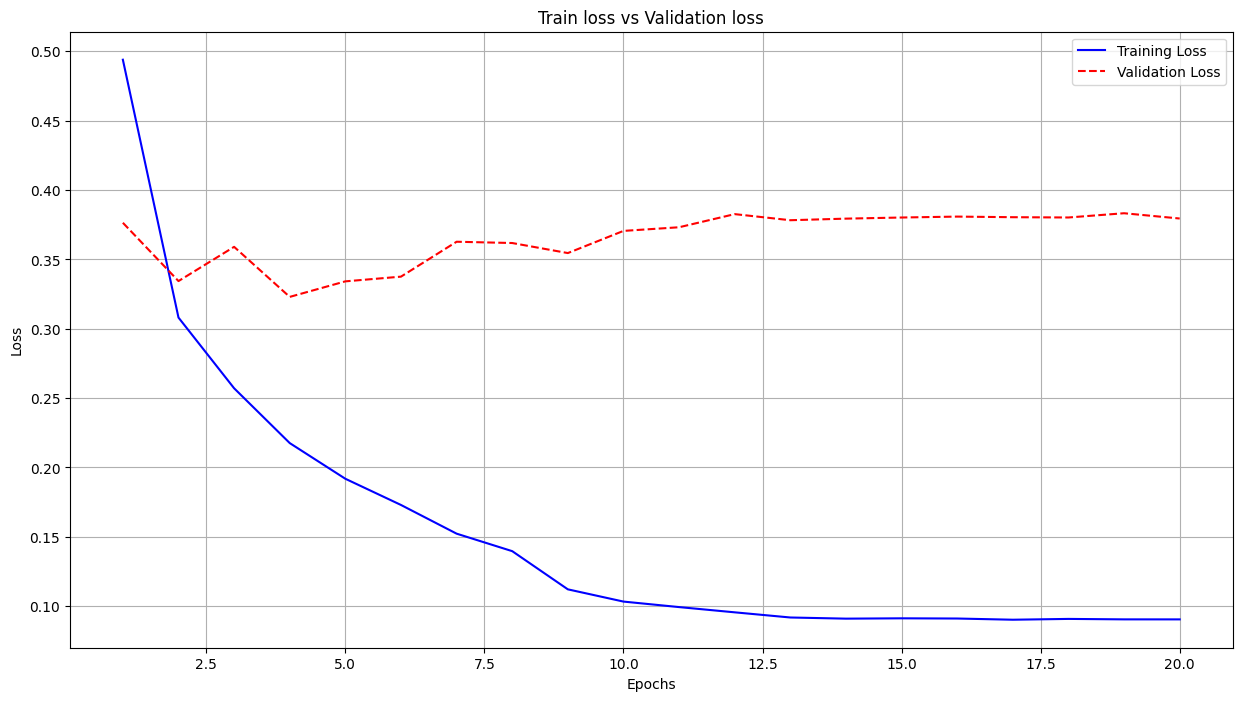

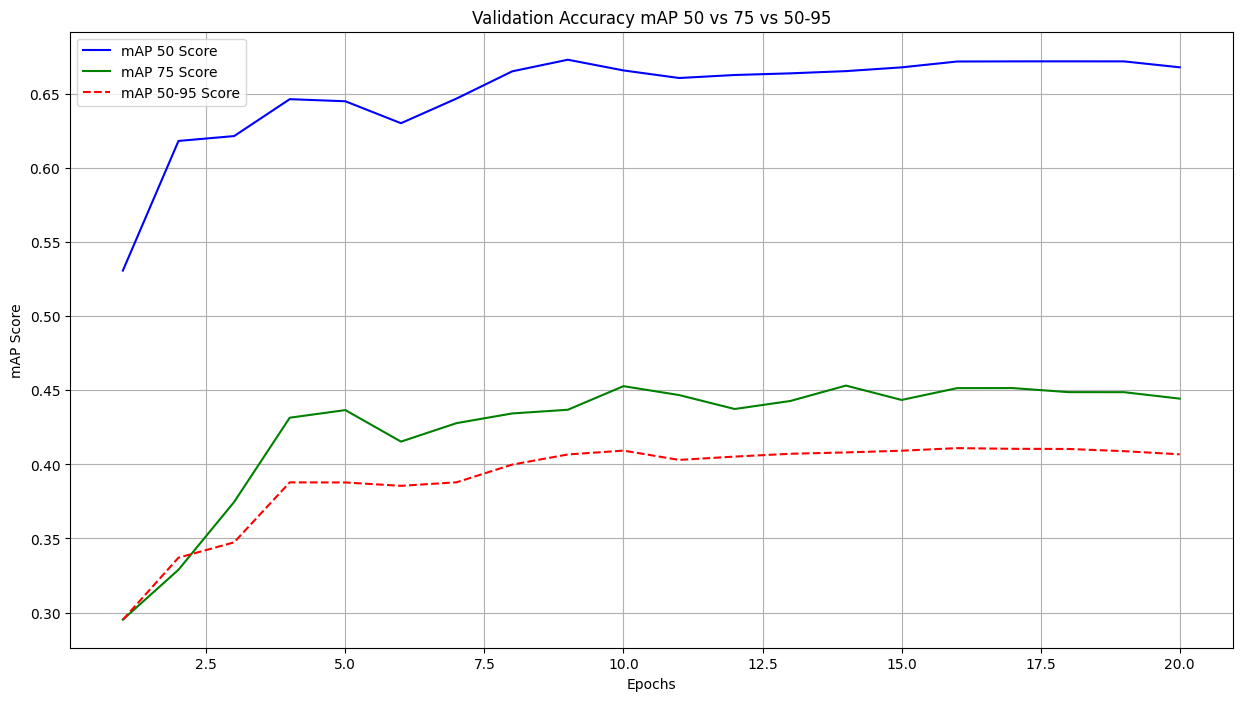

In [ ]:
train_model(20, model, 0.01)

In [ ]:
eval_model(model)

Overall test loss: 0.341294
mAP50-95: 0.476154
mAP50: 0.763578
mAP75: 0.506840
mAP_Small: 0.408481
mAP_Medium: 0.565973
mAP_Large: 0.871521
mAP_per_class: tensor([0.6093, 0.4549, 0.3643])
mAR_100_per_class: tensor([0.6642, 0.5506, 0.5000])
classes: tensor([1, 2, 3], dtype=torch.int32)
Precision: 0.538616
Recall: 0.574078


### Save the model if needed

# Save the model state_dict (only the learned parameters)
torch.save(model.state_dict(), r"D:\ECE 1508\Project\model.pth")
print("Model saved.")

### Reload the model if needed

# Reload the model
# Create a new instance of the model
model_loaded = #SimpleNN()

# Load the saved model state_dict
model_loaded.load_state_dict(torch.load(r"D:\ECE 1508\Project\model.pth"))
model_loaded.eval()  # Set the model to evaluation mode (important for inference)

## Visualization

In [ ]:
#preprocess_images(images_l[0], target_size)

In [ ]:
def extract_img(batch_num, img_num): # img_num should be less than batch size - 1
    batch = []
    for batch_idx, (images, targets) in enumerate(testloader):
        batch.append((images, targets))
    batch_selected = batch[batch_num]
    img = batch_selected[0][img_num]
    t = batch_selected[1][img_num]
    return img, t

In [ ]:
image_test, target_test = extract_img(8, 4)

In [ ]:
# Preprocess the image (resize, normalize, etc., to match your training)
image_tensor = image_test.to(device)  # Move to the same device as the model
#image_test = image_tensor  # Add batch dimension (1, C, H, W)

In [ ]:
# Set model to evaluation mode
model.eval()
with torch.no_grad():
    predictions = model([image_tensor])
# Extract predictions
predicted_boxes = predictions[0]["boxes"].cpu().numpy()  # Bounding boxes
predicted_scores = predictions[0]["scores"].cpu().numpy()  # Confidence scores
predicted_labels = predictions[0]["labels"].cpu().numpy()  # Labels

In [ ]:
predictions

[{'boxes': tensor([[329.9601,  76.5927, 357.2694, 117.3320],
          [253.0916,  72.1361, 281.0715, 110.7632],
          [301.1404,  92.7283, 321.2693, 125.7246],
          [129.0781,  82.7951, 162.7682, 121.6758],
          [368.9050, 101.2613, 374.7039, 128.3611],
          [  1.1032, 182.5147,   7.8668, 208.1003],
          [  2.8458, 184.2290,  16.5885, 209.0611],
          [139.2278, 199.6080, 149.9846, 244.6166],
          [358.5641, 105.6968, 372.8372, 128.0855]], device='cuda:0'),
  'labels': tensor([1, 1, 1, 1, 1, 1, 1, 2, 1], device='cuda:0'),
  'scores': tensor([0.9995, 0.9995, 0.9995, 0.9994, 0.3695, 0.3631, 0.3516, 0.1849, 0.0611],
         device='cuda:0')}]

In [ ]:
target_test

{'boxes': tensor([[129.7200,  82.7200, 160.7400, 124.0800],
         [250.9800,  73.9467, 281.0600, 107.7867],
         [302.6800,  95.2533, 321.4800, 125.3333],
         [330.8800,  77.7067, 357.2000, 117.8133],
         [354.3800, 104.0267, 370.3600, 127.8400]]),
 'labels': tensor([1, 1, 1, 1, 1])}

### We have to use non maximum suppression to eliminate the overlapped boxes and their associated labels using mAP@50, which we reference as our model metric (IoU Threshold)

In [ ]:
def get_nms_pred(pred, iou_threshold):
    batch_boxes = []   # To store filtered boxes for the batch
    batch_scores = []  # To store filtered scores for the batch
    batch_labels = []  # To store filtered labels for the batch
    for item in pred:  # Iterate over each image in the batch
        boxes = item['boxes']
        scores = item['scores']
        labels = item['labels']

        # Apply NMS (non-max suppression)
        indices = nms(boxes, scores, iou_threshold)
        nms_boxes = boxes[indices]
        nms_scores = scores[indices]
        nms_labels = labels[indices]

        # Filter based on score threshold
        score_threshold = 0.5
        final_indices = nms_scores >= score_threshold
        final_boxes = nms_boxes[final_indices]
        final_scores = nms_scores[final_indices]
        final_labels = nms_labels[final_indices]
        # Collect filtered results
        batch_boxes.append(final_boxes.cpu().numpy())
        batch_scores.append(final_scores.cpu().numpy())
        batch_labels.append(final_labels.cpu().numpy())

    return batch_boxes, batch_scores, batch_labels

In [ ]:
nms_boxes, nms_scores, nms_labels = get_nms_pred(predictions, 0.5)

In [ ]:
nms_boxes, nms_scores, nms_labels

([array([[329.9601  ,  76.59271 , 357.26944 , 117.332016],
         [253.09155 ,  72.13614 , 281.07147 , 110.76318 ],
         [301.14035 ,  92.72833 , 321.26926 , 125.72459 ],
         [129.07808 ,  82.79512 , 162.76819 , 121.67583 ]], dtype=float32)],
 [array([0.99951255, 0.9995023 , 0.9994972 , 0.99940956], dtype=float32)],
 [array([1, 1, 1, 1])])

In [ ]:
def draw_comparison(image, target_test, predicted_boxes, predicted_labels):
    image = image.cpu().permute(1,2,0).numpy()
    if len(image.shape) == 3 and image.shape[2] == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    axes[0].imshow(image)
    for i, x in enumerate(target_test['boxes'].cpu().numpy()):
        xmin, ymin, xmax, ymax = x
        label = target_test["labels"].cpu().numpy()[i]
        if label == 1:
            label = 'with_mask'
        elif label == 2:
            label = 'without_mask'
        else:
            label = 'mask_weared_incorrect'
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor='green', facecolor='none'
        )
        axes[0].add_patch(rect)
        axes[0].text(xmin-2, ymin - 10, label, color='red', fontsize=10, weight='bold')
    axes[0].axis('off')  # Hide axis
    axes[0].set_title('Original')

    axes[1].imshow(image)
    for i, x in enumerate(predicted_boxes[0]):
        xmin, ymin, xmax, ymax = x
        label = predicted_labels[0][i]
        if label == 1:
            label = 'with_mask'
        elif label == 2:
            label = 'without_mask'
        else:
            label = 'mask_weared_incorrect'
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor='green', facecolor='none'
        )
        axes[1].add_patch(rect)
        axes[1].text(xmin-2, ymin - 10, label, color='red', fontsize=10, weight='bold')
    axes[1].axis('off')  # Hide axis
    axes[1].set_title('Prediction')
    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

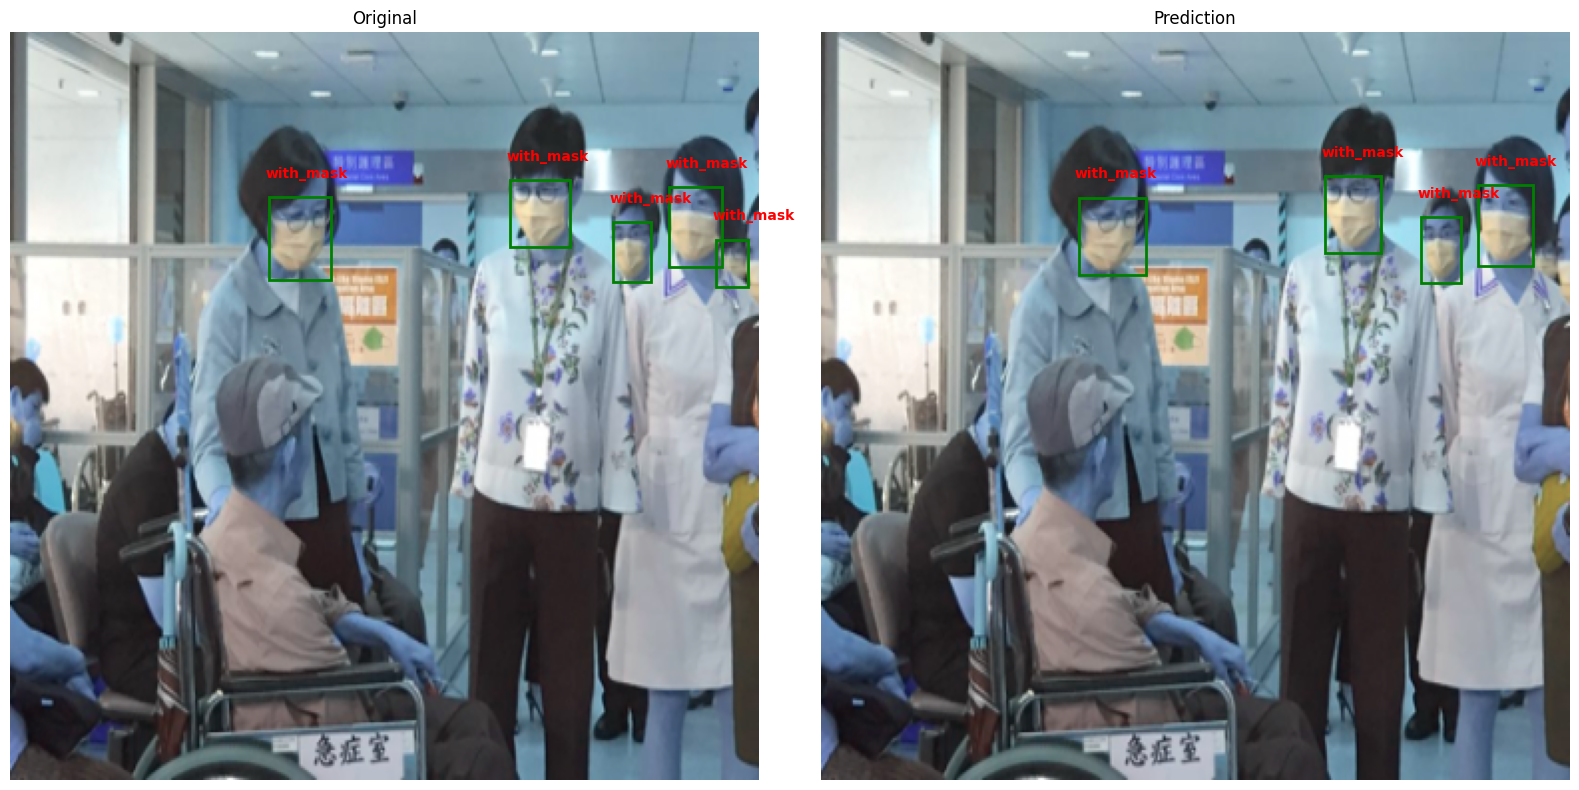

In [ ]:
draw_comparison(image_tensor, target_test, nms_boxes, nms_labels)

### Change # trainable layers in backbone to 2 (default is 3, freeze some layers)

In [ ]:
model_f = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT', trainable_backbone_layers=2)
model_f.roi_heads.box_predictor.cls_score = nn.Linear(in_features, num_classes)
model_f.roi_heads.box_predictor.bbox_pred = nn.Linear(in_features, 4 * num_classes)
model_f.roi_heads.loss = custom_roi_heads_loss
model_f.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

  5%|▌         | 1/20 [00:28<09:03, 28.61s/it]

Epoch 1/20, Train Loss: 0.524233, Validation Loss: 0.401701, Validation mAP50: 0.505014, Validation mAP75: 0.288528, Validation mAP50-95: 0.279103, Precision: 0.448875, mAP50-95 for each class 1, 2, 3: tensor([0.5442, 0.2825, 0.0106])


 10%|█         | 2/20 [00:56<08:32, 28.46s/it]

Epoch 2/20, Train Loss: 0.322722, Validation Loss: 0.351319, Validation mAP50: 0.591040, Validation mAP75: 0.315611, Validation mAP50-95: 0.319360, Precision: 0.568290, mAP50-95 for each class 1, 2, 3: tensor([0.5285, 0.3637, 0.0659])


 15%|█▌        | 3/20 [01:25<08:02, 28.39s/it]

...

Epoch 18/20, Train Loss: 0.094712, Validation Loss: 0.379834, Validation mAP50: 0.638287, Validation mAP75: 0.453569, Validation mAP50-95: 0.402047, Precision: 0.610799, mAP50-95 for each class 1, 2, 3: tensor([0.5959, 0.4290, 0.1812])


 95%|█████████▌| 19/20 [08:51<00:27, 27.79s/it]

Epoch 19/20, Train Loss: 0.094699, Validation Loss: 0.383905, Validation mAP50: 0.638314, Validation mAP75: 0.453835, Validation mAP50-95: 0.402123, Precision: 0.610807, mAP50-95 for each class 1, 2, 3: tensor([0.5959, 0.4293, 0.1812])


100%|██████████| 20/20 [09:18<00:00, 27.95s/it]

Epoch 20/20, Train Loss: 0.094946, Validation Loss: 0.380909, Validation mAP50: 0.638315, Validation mAP75: 0.453822, Validation mAP50-95: 0.402066, Precision: 0.610805, mAP50-95 for each class 1, 2, 3: tensor([0.5956, 0.4294, 0.1812])


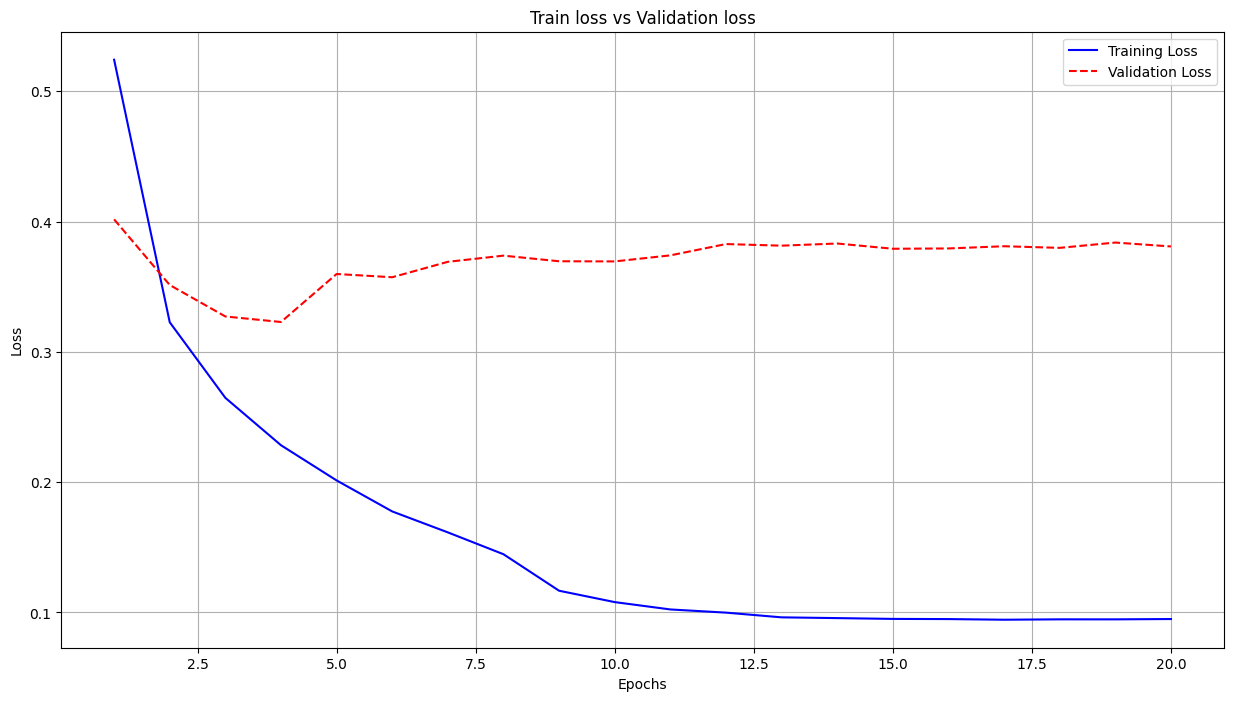

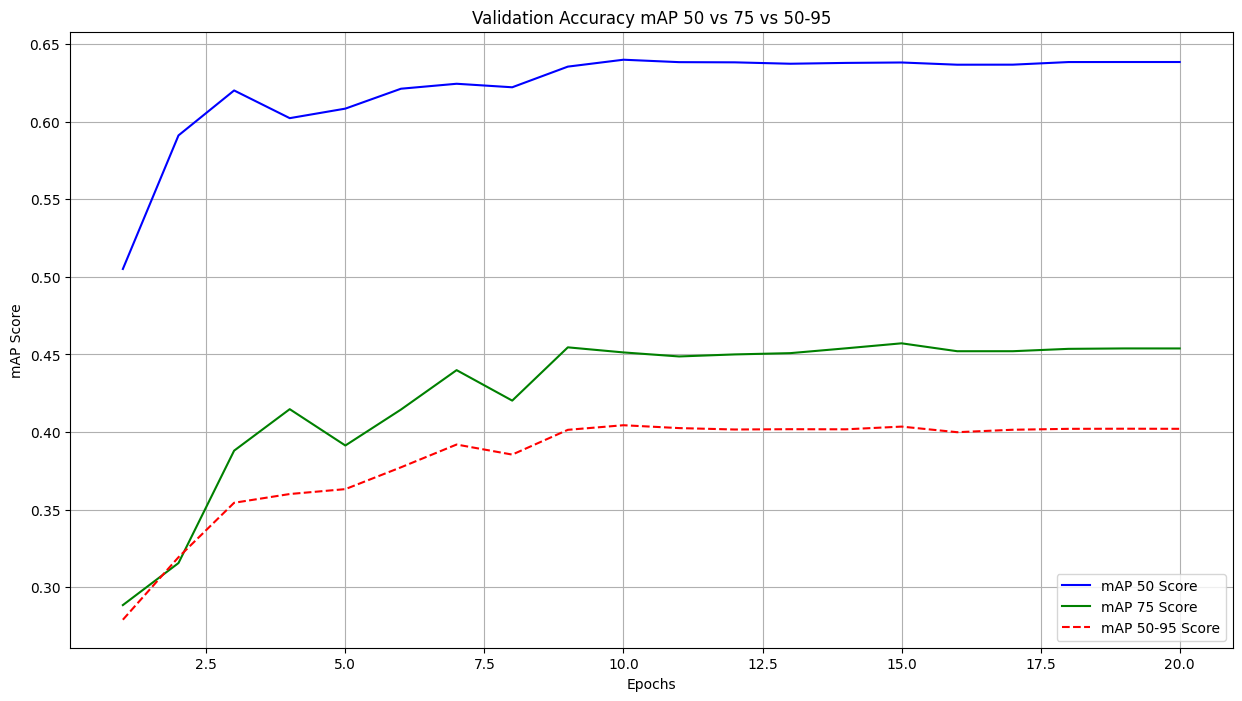

In [ ]:
train_model(20, model_f, 0.01)

In [ ]:
eval_model(model_f)

Overall test loss: 0.347303
mAP50-95: 0.475447
mAP50: 0.748777
mAP75: 0.541267
mAP_Small: 0.393390
mAP_Medium: 0.571591
mAP_Large: 0.871512
mAP_per_class: tensor([0.6103, 0.4542, 0.3618])
mAR_100_per_class: tensor([0.6674, 0.5468, 0.5000])
classes: tensor([1, 2, 3], dtype=torch.int32)
Precision: 0.529255
Recall: 0.572870


### Add Dropout

In [ ]:
# Load the pre-trained Faster R-CNN model
model_d = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')

# Inspect the ROI head (classification head)
print(model_d.roi_heads)

# Modify the box predictor (fully connected layers with dropout)
in_features = model_d.roi_heads.box_predictor.cls_score.in_features
num_classes = 4 # 3+1 classes
in_chnl, rep_size = 12544, 1024 # Inspect the original model features

# Define custom TwoMLPHead
class CustomTwoMLPHead(nn.Module):
    def __init__(self, in_channels, representation_size, dropout_prob=0.5):
        super(CustomTwoMLPHead, self).__init__()
        self.fc6 = nn.Linear(in_channels, representation_size)
        self.dropout = nn.Dropout(p=dropout_prob)  # Add dropout
        self.fc7 = nn.Linear(representation_size, representation_size)

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = self.fc6(x)
        x = nn.ReLU()(x)
        x = self.dropout(x)  # Apply dropout here
        x = self.fc7(x)
        x = nn.ReLU()(x)
        return x

# Freeze all layers in the backbone
#for param in model_d.backbone.body.parameters():
#    param.requires_grad = False

# Replace the box head with the custom one
model_d.roi_heads.box_head = CustomTwoMLPHead(in_chnl, rep_size, dropout_prob=0.5)

# Replace the classification head with the custom one
model_d.roi_heads.box_predictor.cls_score = nn.Linear(in_features, num_classes)
model_d.roi_heads.box_predictor.bbox_pred = nn.Linear(in_features, 4*num_classes)

# Replace the default loss function in roi_heads
model_d.roi_heads.loss = custom_roi_heads_loss

# Inspect revised ROI head
print(model_d.roi_heads)

RoIHeads(
  (box_roi_pool): MultiScaleRoIAlign(featmap_names=['0', '1', '2', '3'], output_size=(7, 7), sampling_ratio=2)
  (box_head): TwoMLPHead(
    (fc6): Linear(in_features=12544, out_features=1024, bias=True)
    (fc7): Linear(in_features=1024, out_features=1024, bias=True)
  )
  (box_predictor): FastRCNNPredictor(
    (cls_score): Linear(in_features=1024, out_features=91, bias=True)
    (bbox_pred): Linear(in_features=1024, out_features=364, bias=True)
  )
)
RoIHeads(
  (box_roi_pool): MultiScaleRoIAlign(featmap_names=['0', '1', '2', '3'], output_size=(7, 7), sampling_ratio=2)
  (box_head): CustomTwoMLPHead(
    (fc6): Linear(in_features=12544, out_features=1024, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
    (fc7): Linear(in_features=1024, out_features=1024, bias=True)
  )
  (box_predictor): FastRCNNPredictor(
    (cls_score): Linear(in_features=1024, out_features=4, bias=True)
    (bbox_pred): Linear(in_features=1024, out_features=16, bias=True)
  )
)


In [ ]:
model_d.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

  5%|▌         | 1/20 [00:31<09:50, 31.06s/it]

Epoch 1/20, Train Loss: 0.642982, Validation Loss: 0.502773, Validation mAP50: 0.488205, Validation mAP75: 0.202655, Validation mAP50-95: 0.237377, Precision: 0.420107, mAP50-95 for each class 1, 2, 3: tensor([0.4909, 0.2170, 0.0042])


 10%|█         | 2/20 [01:01<09:12, 30.69s/it]

Epoch 2/20, Train Loss: 0.408515, Validation Loss: 0.406281, Validation mAP50: 0.572849, Validation mAP75: 0.307750, Validation mAP50-95: 0.314798, Precision: 0.522728, mAP50-95 for each class 1, 2, 3: tensor([0.5419, 0.3513, 0.0512])


 15%|█▌        | 3/20 [01:31<08:38, 30.53s/it]

...

Epoch 18/20, Train Loss: 0.150960, Validation Loss: 0.401062, Validation mAP50: 0.629579, Validation mAP75: 0.392779, Validation mAP50-95: 0.370167, Precision: 0.607586, mAP50-95 for each class 1, 2, 3: tensor([0.5656, 0.3941, 0.1508])


 95%|█████████▌| 19/20 [09:31<00:29, 29.90s/it]

Epoch 19/20, Train Loss: 0.150804, Validation Loss: 0.397939, Validation mAP50: 0.632160, Validation mAP75: 0.395369, Validation mAP50-95: 0.372272, Precision: 0.608228, mAP50-95 for each class 1, 2, 3: tensor([0.5656, 0.3950, 0.1562])


100%|██████████| 20/20 [10:01<00:00, 30.06s/it]

Epoch 20/20, Train Loss: 0.151473, Validation Loss: 0.402803, Validation mAP50: 0.632182, Validation mAP75: 0.395361, Validation mAP50-95: 0.371990, Precision: 0.608234, mAP50-95 for each class 1, 2, 3: tensor([0.5656, 0.3942, 0.1562])


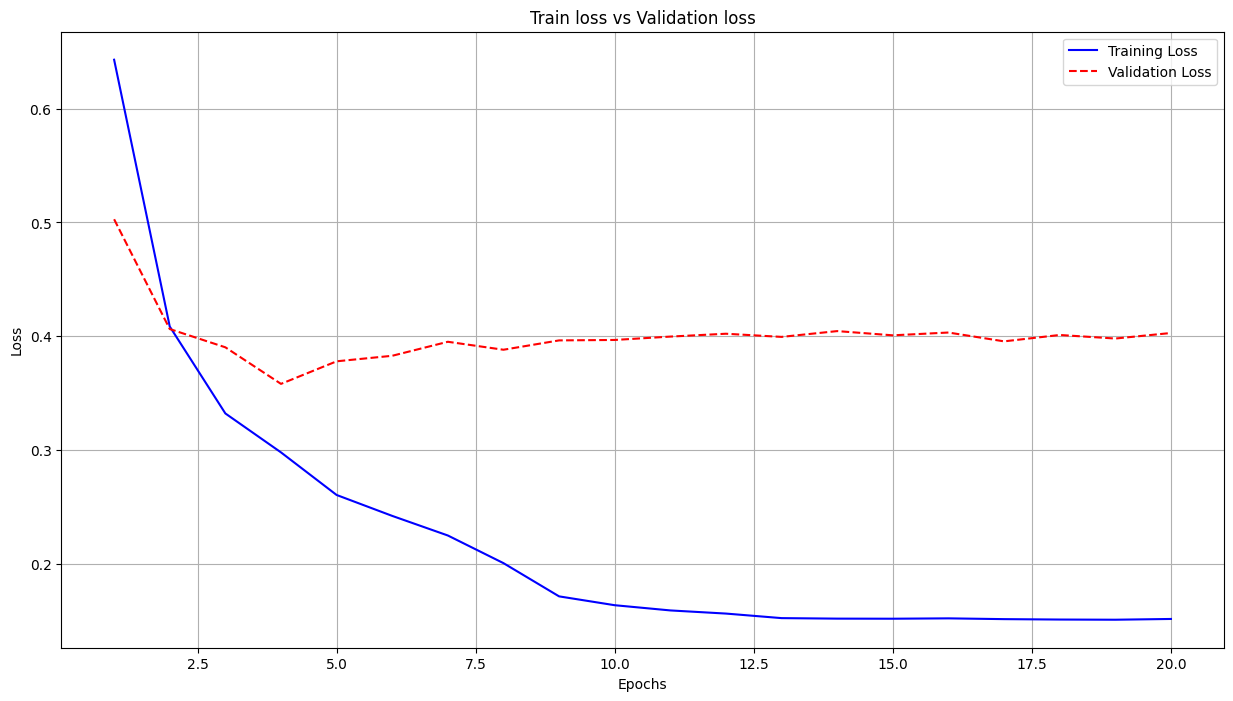

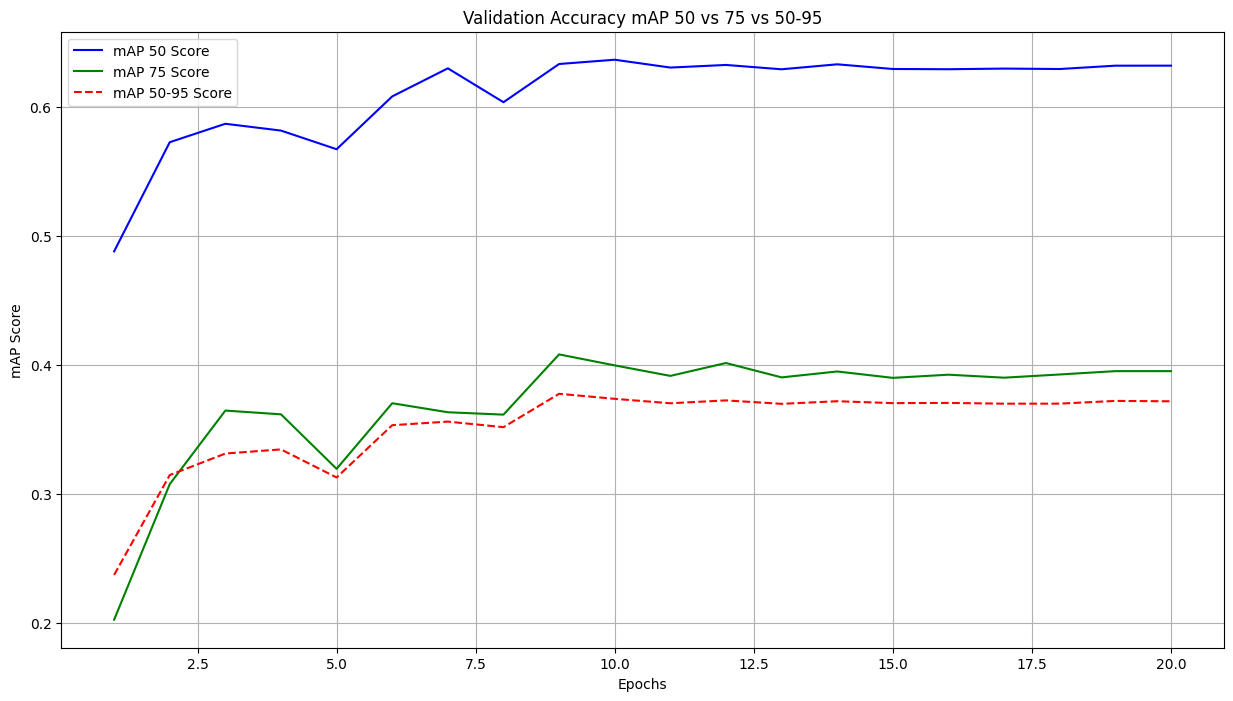

In [ ]:
train_model(20, model_d, 0.01)

In [ ]:
eval_model(model_d)

Overall test loss: 0.380665
mAP50-95: 0.409576
mAP50: 0.688138
mAP75: 0.430886
mAP_Small: 0.349629
mAP_Medium: 0.489793
mAP_Large: 0.825768
mAP_per_class: tensor([0.5866, 0.4166, 0.2255])
mAR_100_per_class: tensor([0.6570, 0.5380, 0.4929])
classes: tensor([1, 2, 3], dtype=torch.int32)
Precision: 0.490125
Recall: 0.595813


### Applied weight decay as well

In [ ]:
# Load the pre-trained Faster R-CNN model
model_dw = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')

in_chnl, rep_size = 12544, 1024 # Inspect the original model features

# Freeze all layers in the backbone
#for param in model_d.backbone.body.parameters():
#    param.requires_grad = False

# Replace the box head with the custom one
model_dw.roi_heads.box_head = CustomTwoMLPHead(in_chnl, rep_size, dropout_prob=0.5)

# Replace the classification head with the custom one
model_dw.roi_heads.box_predictor.cls_score = nn.Linear(in_features, num_classes)
model_dw.roi_heads.box_predictor.bbox_pred = nn.Linear(in_features, 4*num_classes)

# Replace the default loss function in roi_heads
model_dw.roi_heads.loss = custom_roi_heads_loss

In [ ]:
model_dw.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

  5%|▌         | 1/20 [00:30<09:44, 30.75s/it]

Epoch 1/20, Train Loss: 0.632467, Validation Loss: 0.524713, Validation mAP50: 0.476339, Validation mAP75: 0.240826, Validation mAP50-95: 0.242914, Precision: 0.418390, mAP50-95 for each class 1, 2, 3: tensor([0.5025, 0.2104, 0.0158])


 10%|█         | 2/20 [01:01<09:09, 30.54s/it]

Epoch 2/20, Train Loss: 0.429515, Validation Loss: 0.439186, Validation mAP50: 0.524987, Validation mAP75: 0.301794, Validation mAP50-95: 0.285476, Precision: 0.485142, mAP50-95 for each class 1, 2, 3: tensor([0.5272, 0.3026, 0.0266])


 15%|█▌        | 3/20 [01:31<08:38, 30.50s/it]

...

Epoch 18/20, Train Loss: 0.277212, Validation Loss: 0.386615, Validation mAP50: 0.601117, Validation mAP75: 0.397251, Validation mAP50-95: 0.350029, Precision: 0.575529, mAP50-95 for each class 1, 2, 3: tensor([0.5590, 0.3790, 0.1121])


 95%|█████████▌| 19/20 [09:36<00:30, 30.29s/it]

Epoch 19/20, Train Loss: 0.277623, Validation Loss: 0.386434, Validation mAP50: 0.597993, Validation mAP75: 0.375067, Validation mAP50-95: 0.344546, Precision: 0.576731, mAP50-95 for each class 1, 2, 3: tensor([0.5627, 0.3754, 0.0956])


100%|██████████| 20/20 [10:06<00:00, 30.33s/it]

Epoch 20/20, Train Loss: 0.276898, Validation Loss: 0.388004, Validation mAP50: 0.600133, Validation mAP75: 0.394812, Validation mAP50-95: 0.348985, Precision: 0.572389, mAP50-95 for each class 1, 2, 3: tensor([0.5608, 0.3805, 0.1056])


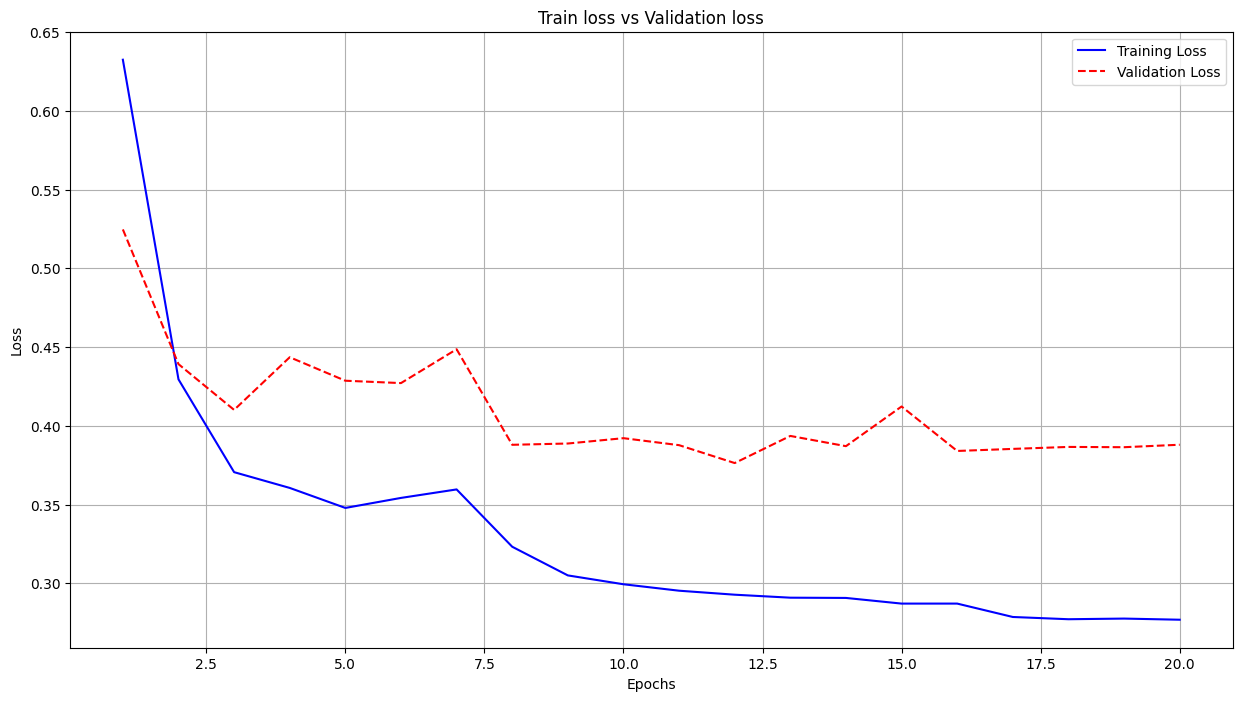

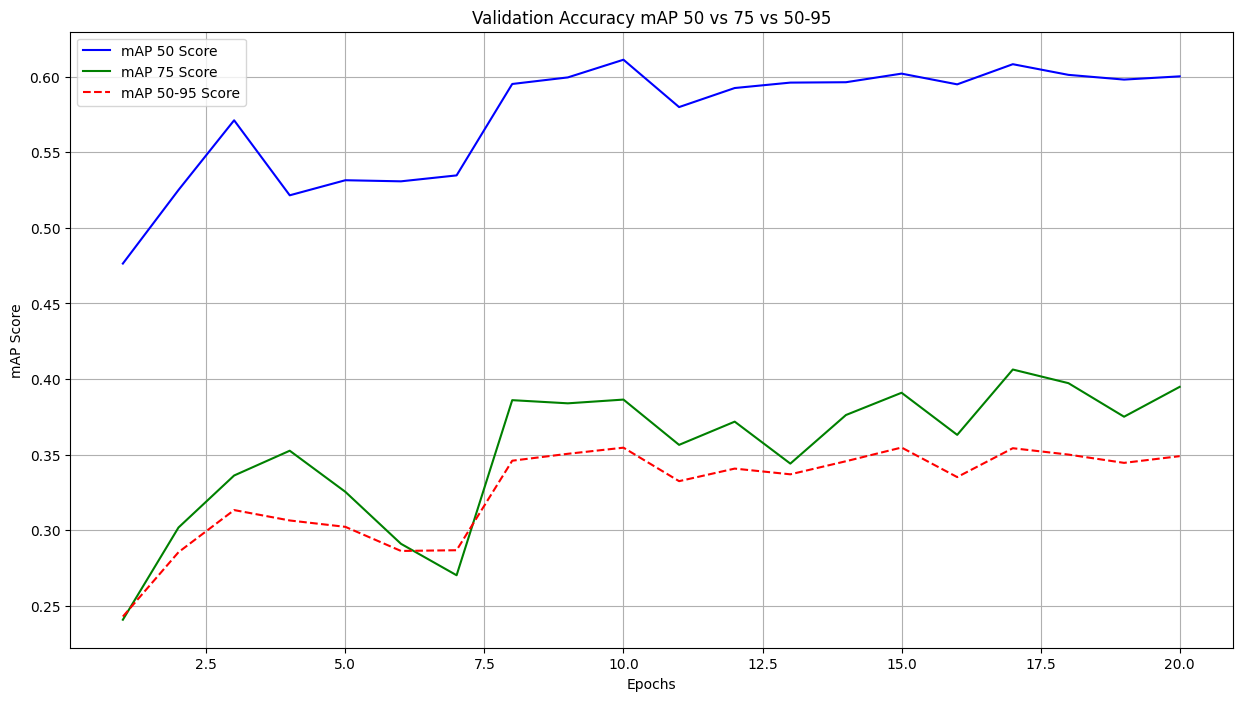

In [ ]:
train_model(20, model_dw, 0.01, 0.01)

In [ ]:
eval_model(model_dw)

Overall test loss: 0.382564
mAP50-95: 0.385160
mAP50: 0.627843
mAP75: 0.437966
mAP_Small: 0.332635
mAP_Medium: 0.469602
mAP_Large: 0.847160
mAP_per_class: tensor([0.5834, 0.4397, 0.1324])
mAR_100_per_class: tensor([0.6527, 0.5570, 0.4214])
classes: tensor([1, 2, 3], dtype=torch.int32)
Precision: 0.461688
Recall: 0.580319
